In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly import express as px
from plotly.subplots import make_subplots
from torch.utils.data import DataLoader, ConcatDataset, RandomSampler, SequentialSampler
import torch

from dataset_utils.dataset import DatasetImageClassifier, load_data, collate_fn
from dataset_utils.readers import ImageReader, LabelReader
from dataset_utils.dataloader import DataLoaderUtils
from utils.config import Settings
settings = Settings()

data = load_data(settings.train_dir)
images_paths = [element[0] for element in data]
labels_paths = [element[1] for element in data]

C:\Users\Kuba\AppData\Roaming\Python\Python311\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.3'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def subplot_continous(data, statistics=["Min", "Med", "Max"], title="", nbins=0):
    rows, columns = 1, 2
    fig = make_subplots(rows=rows, cols=columns, specs=[[{"type": "box"}, {"type": "histogram"}] for i in range(0, rows)])
    fig.add_trace(go.Box(y=data, name="Box", showlegend=False, marker=dict(color="rgb(102,197,204)")), row=1, col=1)
    fig.add_trace(go.Histogram(x=data, name="Histogram", showlegend=False, marker=dict(color="rgb(135,197,95)"), nbinsx=nbins), row=1, col=2)
    possible_statistics = {"Min": np.min(data), "Med": np.median(data), "Max": np.max(data)}
    for x in statistics:
        fig.add_annotation(x=0.4, y=possible_statistics[x], text=f"{x}: {round(possible_statistics[x], 3)}", showarrow=False)
    fig.update_layout(template="simple_white", width=1200, height=800, title=f"<b>{title}<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
    fig.show("png")

def generate_bar_chart(train_data, valid_data, test_data, colors):
    fig = go.Figure()
    for class_name in settings.class_names:
        train_count = len([1 for _, label in train_data if label == class_name])
        valid_count = len([1 for _, label in valid_data if label == class_name])
        test_count = len([1 for _, label in test_data if label == class_name])
        counts = [train_count, valid_count, test_count]
        percent = [round(count/sum(counts)*100, 2) for count in counts]
        fig.add_trace(go.Bar(name=class_name, x=["Train", "Valid", "Test"], y=counts, text=[f"{count}<br>({percent}%) " for count, percent in zip(counts, percent)], marker=dict(color=colors[settings.class_names.index(class_name)])))
    fig.update_layout(template="simple_white", width=1200, height=800, title="<b>Number of images in each class<b>", title_x=0.5, font=dict(family="Times New Roman",size=16,color="Black"))
    fig.show("png")

colors = px.colors.qualitative.Bold

In [3]:
train_count = len(load_data(settings.train_dir))
valid_count = len(load_data(settings.valid_dir))
test_count = len(load_data(settings.test_dir))
all_count = train_count + valid_count + test_count
print(f"Number of images:")
print(f"\t- Train: {train_count} ({100*round(train_count/all_count, 4)}%)")
print(f"\t- Valid: {valid_count} ({100*round(valid_count/all_count, 4)}%)")
print(f"\t- Test: {test_count} ({100*round(test_count/all_count, 4)}%)")
print(f"\t- All: {all_count}")

Number of images:
	- Train: 88534 (70.0%)
	- Valid: 18973 (15.0%)
	- Test: 18975 (15.0%)
	- All: 126482


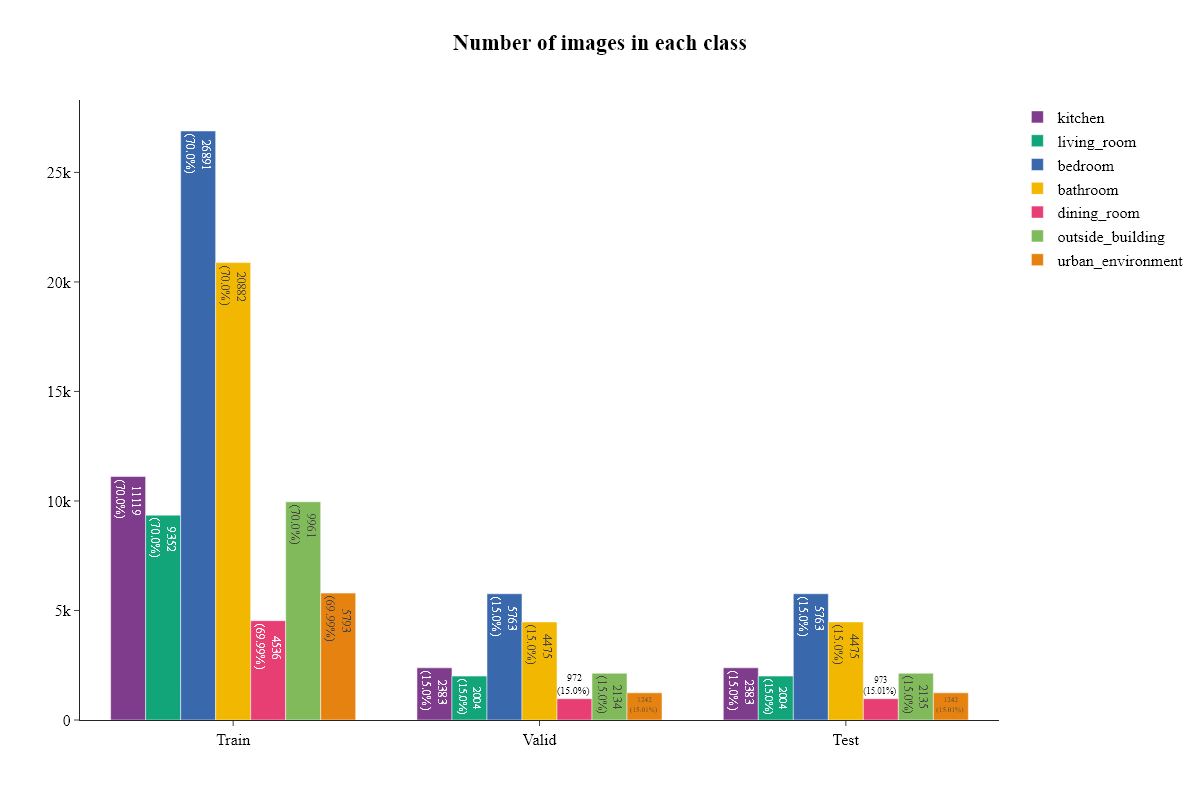

In [4]:
train_data = load_data(settings.train_dir)
valid_data = load_data(settings.valid_dir)
test_data = load_data(settings.test_dir)
generate_bar_chart(train_data, valid_data, test_data, colors)

## Stosunek szerokość/wysokość obrazów wejściowych

In [5]:
def images_width_height(images_paths):
    heights, widths, aspect_ratios = [], [], []
    for idx, file_path in enumerate(images_paths):
        if(file_path.endswith(".png") == False):
            continue
        image = cv2.imread(file_path)
        heights.append(image.shape[0])
        widths.append(image.shape[1])
        aspect_ratios.append(image.shape[1]/image.shape[0])
    return heights, widths, aspect_ratios
heights, widths, aspect_ratios = images_width_height(images_paths)

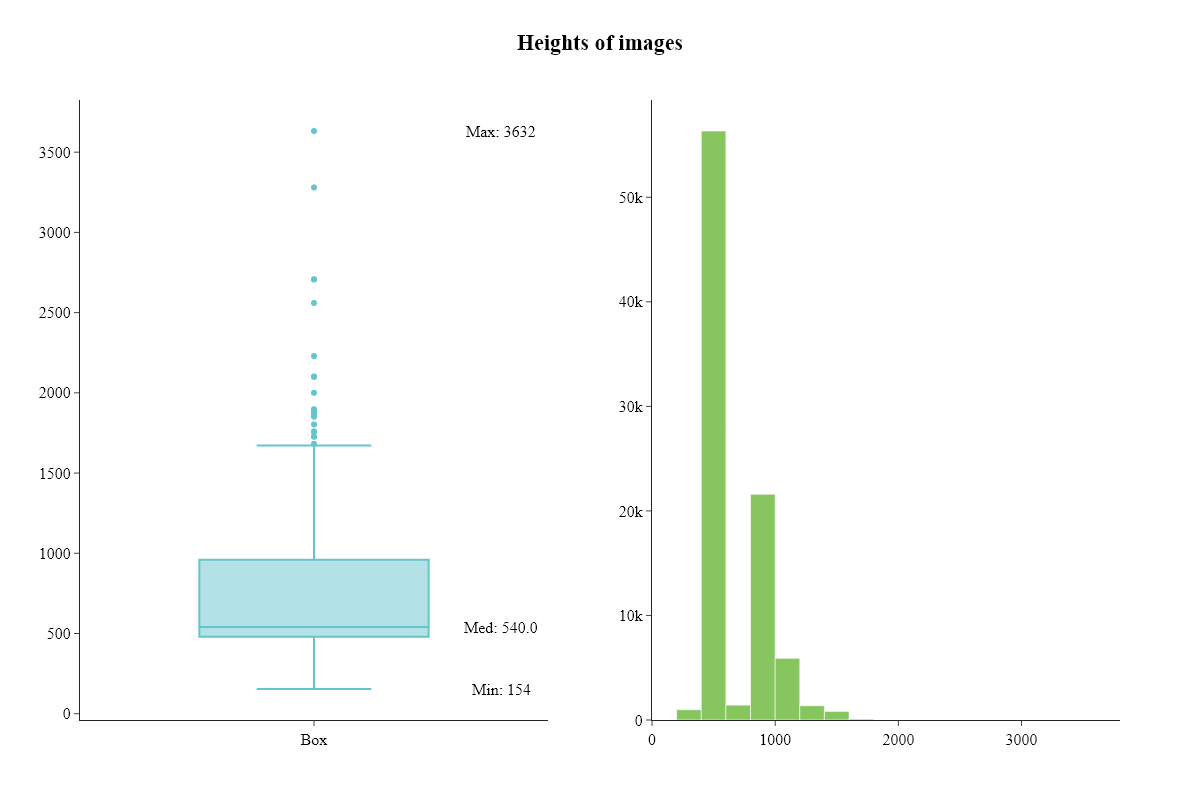

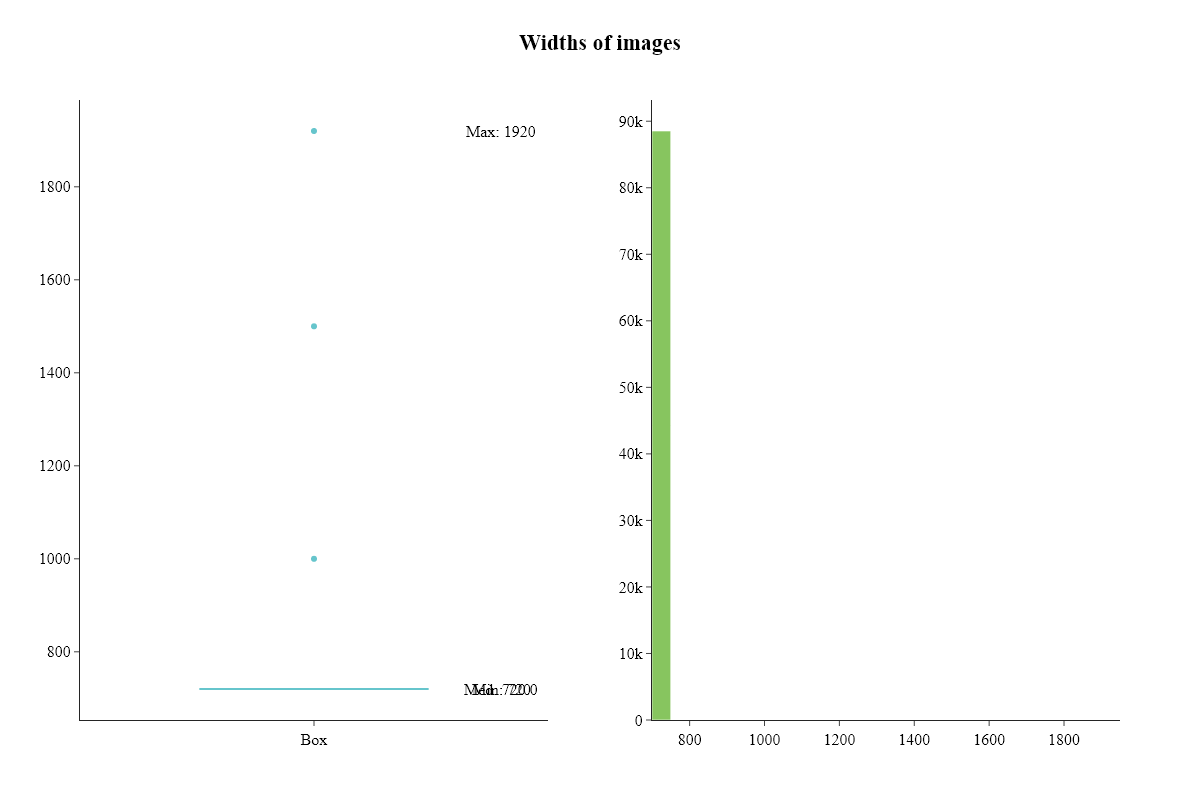

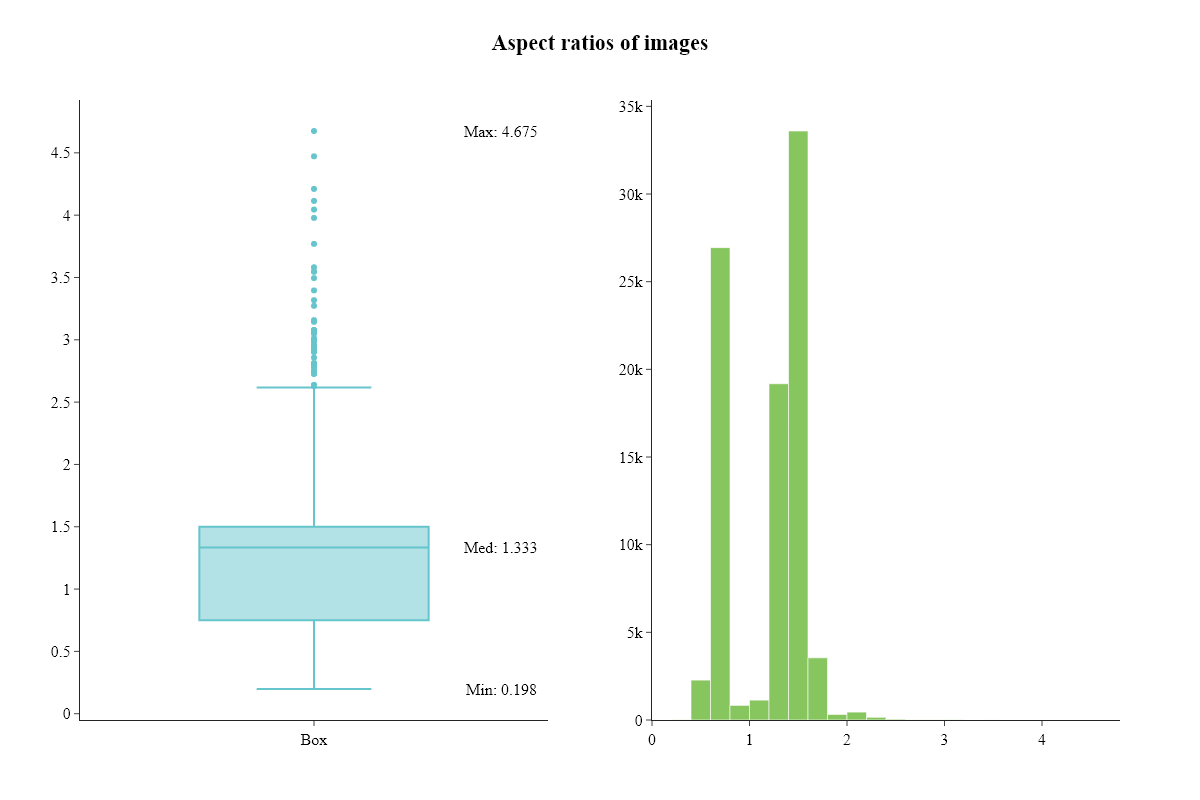

Median height: 540
Median width: 720
Median aspect ratio: 1.3333333333333333


In [6]:
subplot_continous(heights, statistics=["Min", "Med", "Max"], title="Heights of images", nbins=30)
subplot_continous(widths, statistics=["Min", "Med", "Max"], title="Widths of images", nbins=30)
subplot_continous(aspect_ratios, statistics=["Min", "Med", "Max"], title="Aspect ratios of images", nbins=30)
median_height = int(np.median(heights))
median_width = int(np.median(widths))
median_aspect_ratio = np.median(aspect_ratios)
print(f"Median height: {median_height}")
print(f"Median width: {median_width}")
print(f"Median aspect ratio: {median_aspect_ratio}")

In [7]:
SMALLEST_MAX_SIZE, HEIGHT, WIDTH = 256, 224, 224

## Normalizacja

In [8]:
data_transforms = {
    "base": A.Compose(
        [
            A.SmallestMaxSize(max_size=SMALLEST_MAX_SIZE, interpolation=cv2.INTER_AREA, p=1),
            A.CenterCrop(HEIGHT, WIDTH, p=1),
            # A.Resize(HEIGHT, WIDTH, interpolation=cv2.INTER_AREA, p=1),
            ToTensorV2(),
        ]
    )}
settings = Settings()
train = DatasetImageClassifier(
    load_data(settings.train_dir),
    readers=[ImageReader(), LabelReader()],
    transforms=data_transforms["base"],
    name="train",
)
train_loader = DataLoader(
    train,
    batch_size=settings.batch_size,
    sampler=RandomSampler(train),
    collate_fn=collate_fn,
)
valid = DatasetImageClassifier(
    load_data(settings.valid_dir),
    readers=[ImageReader(), LabelReader()],
    transforms=data_transforms["base"],
    name="valid",
)
valid_loader = DataLoader(
    valid,
    batch_size=settings.batch_size,
    sampler=RandomSampler(valid),
    collate_fn=collate_fn,
)

test = DatasetImageClassifier(
    load_data(settings.test_dir),
    readers=[ImageReader(), LabelReader()],
    transforms=data_transforms["base"],
    name="test",
)
test_loader = DataLoader(
    test,
    batch_size=settings.batch_size,
    sampler=RandomSampler(test),
    collate_fn=collate_fn,
)
def mean_std(loader):
    mean = 0.0
    std = 0.0
    total_images_count = 0
    for idx, (inputs, _) in enumerate(loader):
        images = torch.stack(inputs)
        image_count_in_a_batch = images.size(0)
        images = images.view(image_count_in_a_batch, images.size(1), -1)
        images = images/255.0
        mean += (images * 1.0).mean(2).sum(0)
        std += (images * 1.0).std(2).sum(0)
        total_images_count += image_count_in_a_batch
    mean /= total_images_count
    std /= total_images_count
    return mean, std
mean, std = mean_std(train_loader)
print("MEAN = {}".format(list(mean.detach().numpy())))
print("STD = {}".format(list(std.detach().numpy())))

MEAN = [0.6032591, 0.56755817, 0.5286094]
STD = [0.20900008, 0.2107773, 0.21879801]


In [9]:
def verify_mean_std(loader, mean, std):
    verified_mean = 0.0
    verified_std = 0.0
    total_images_count = 0
    for idx, (inputs, _) in enumerate(loader):
        images = torch.stack(inputs)
        image_count_in_a_batch = images.size(0)
        images = images/255.0
        images = images - mean[None, :, None, None]
        images = images / std[None, :, None, None]
        images = images.view(image_count_in_a_batch, images.size(1), -1)
        verified_mean += (images * 1.0).mean(2).sum(0)
        verified_std += (images * 1.0).std(2).sum(0)
        total_images_count += image_count_in_a_batch
    verified_mean /= total_images_count
    verified_std /= total_images_count
    return verified_mean, verified_std
train_mean, train_std = verify_mean_std(train_loader, mean, std)
print("Mean should be: [0, 0, 0]")
print("Std should be: [1, 1, 1]")
print("Train images after applying normalization:")
print(f"\t- Mean: {list(train_mean.detach().numpy())}")
print(f"\t- Std: {list(train_std.detach().numpy())}")
valid_mean, valid_std = verify_mean_std(valid_loader, mean, std)
print("Valid images after applying normalization:")
print(f"\t- Mean: {list(valid_mean.detach().numpy())}")
print(f"\t- Std: {list(valid_std.detach().numpy())}")
test_mean, test_std = verify_mean_std(test_loader, mean, std)
print("Test images after applying normalization:")
print(f"\t- Mean: {list(test_mean.detach().numpy())}")
print(f"\t- Std: {list(test_std.detach().numpy())}")

Mean should be: [0, 0, 0]
Std should be: [1, 1, 1]
Train images after applying normalization:
	- Mean: [2.8173606e-06, 2.237301e-06, -5.587274e-07]
	- Std: [0.99999964, 1.0000012, 1.0000007]
Valid images after applying normalization:
	- Mean: [-0.004567319, -0.0084329005, -0.009795024]
	- Std: [0.99824184, 0.99821633, 0.9968827]
Test images after applying normalization:
	- Mean: [0.00013758377, -0.0017268062, -0.002004614]
	- Std: [1.0007256, 1.0003239, 0.997987]


# Show augmentation

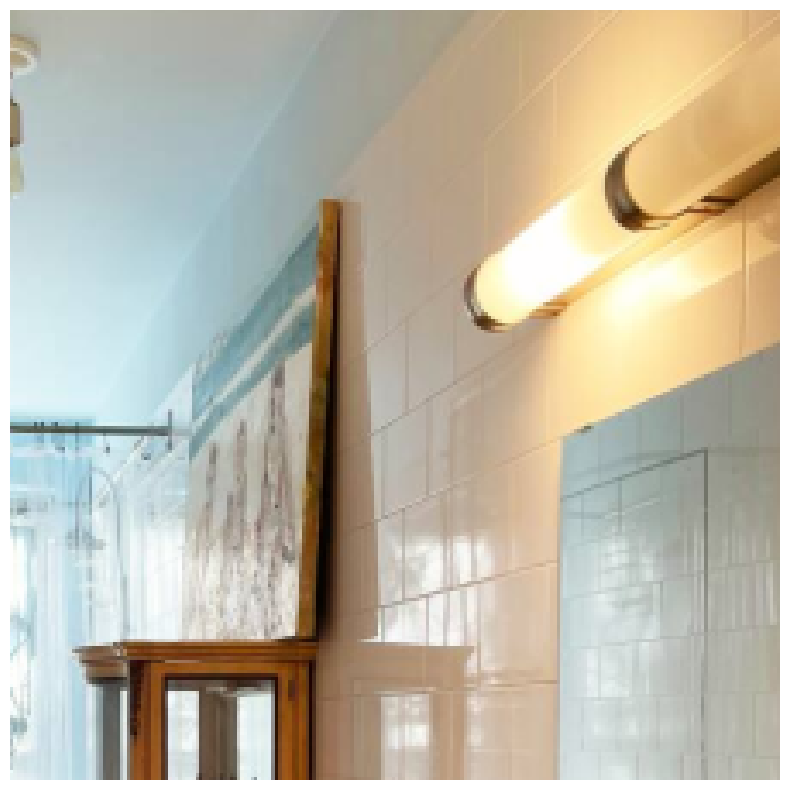

In [16]:
data_transforms = {
    "augment":  A.Compose(
        [
            # A.SmallestMaxSize(max_size=settings.SMALLEST_MAX_SIZE, interpolation=cv2.INTER_AREA, p=1),
            A.RandomResizedCrop((HEIGHT, WIDTH), interpolation=cv2.INTER_AREA, p=1),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.Perspective(scale=0.2, p=0.5),
            A.MotionBlur(p=0.2),
            A.GridDistortion(p=0.2),
            A.Normalize(
                settings.MEAN,
                settings.STD,
                normalization="standard",
            ),
            ToTensorV2(),
        ]
    )}

train = DatasetImageClassifier(
    load_data(settings.train_dir),
    readers=[ImageReader(), LabelReader()],
    transforms=data_transforms["augment"],
    name="train",
)

train_loader = DataLoader(
    train,
    batch_size=settings.batch_size,
    sampler=RandomSampler(train),
    collate_fn=collate_fn,
)

for idx, (inputs, labels) in enumerate(train_loader):
    image = inputs[0].permute(1, 2, 0).numpy()
    image = image * settings.STD + settings.MEAN
    image = np.clip(image, 0, 1)
    image = (image * 255).astype(np.uint8)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
    break